### Regression Problem

In [213]:
import pandas as pd
import numpy as np

**Data Preparation**

In [214]:
raw_data = pd.read_csv("../Datasets/data.csv")
df = raw_data.copy()

**First Look of data**

In [215]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [216]:
df.columns = df.columns.str.lower().str.replace(" ","_",regex=False)

In [217]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings 

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [218]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(" ","_",regex=False)

In [219]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


**Exploratory data analysis**

In [220]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print("unique:",df[col].nunique())
    print("_"*50)

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
unique: 48
__________________________________________________
model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
unique: 914
__________________________________________________
year
[2011 2012 2013 1992 1993]
unique: 28
__________________________________________________
engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
unique: 10
__________________________________________________
engine_hp
[335. 300. 230. 320. 172.]
unique: 356
__________________________________________________
engine_cylinders
[ 6.  4.  5.  8. 12.]
unique: 9
__________________________________________________
transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unk

**distribution of price**

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

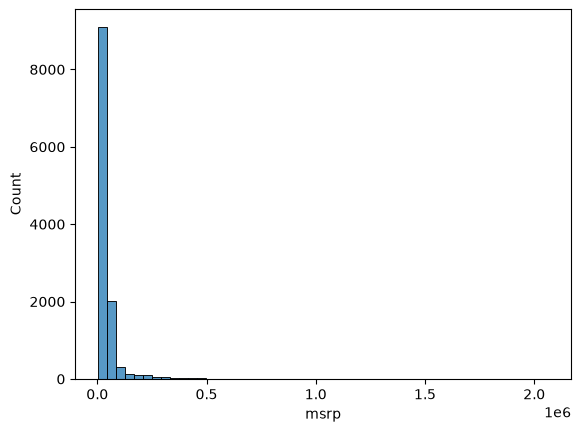

In [222]:
sns.histplot(df["msrp"],bins=50)

* Long tail distrubtion

<Axes: xlabel='msrp', ylabel='Count'>

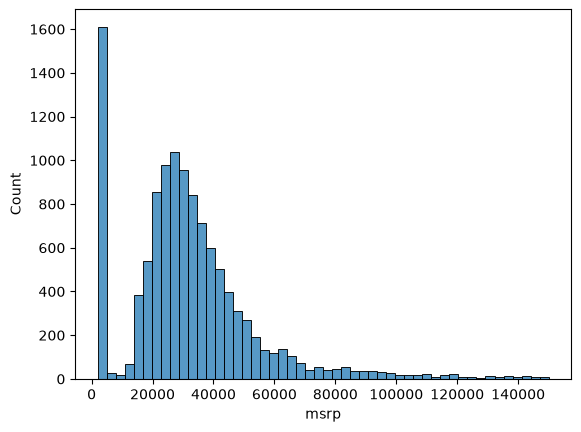

In [223]:
sns.histplot(df["msrp"][df["msrp"]<150000],bins=50)

In [224]:
np.log([1,10,100,100000])

array([ 0.        ,  2.30258509,  4.60517019, 11.51292546])

In [225]:
np.log([0,1,10,100,100000])

C:\Users\avina\AppData\Local\Temp\ipykernel_13476\1950038018.py:1: RuntimeWarning: divide by zero encountered in log
  np.log([0,1,10,100,100000])


array([       -inf,  0.        ,  2.30258509,  4.60517019, 11.51292546])

In [226]:
np.log([0+1,1+1,10+1,100+1,100000+1])

array([ 0.        ,  0.69314718,  2.39789527,  4.61512052, 11.51293546])

In [227]:
np.log1p([0,1,10,100,100000])

array([ 0.        ,  0.69314718,  2.39789527,  4.61512052, 11.51293546])

<Axes: xlabel='msrp', ylabel='Count'>

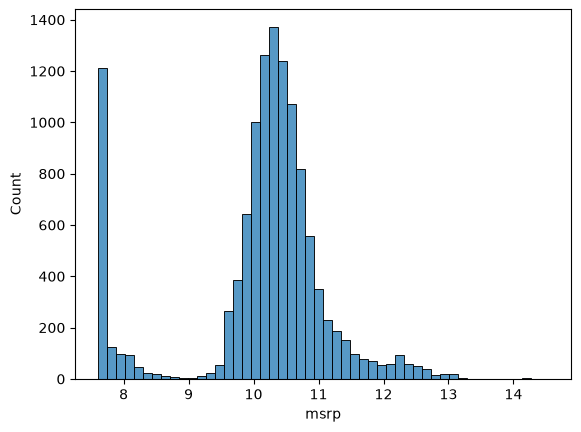

In [228]:
price_log =np.log1p(df.msrp)
sns.histplot(price_log,bins=50)

**Missing values**

In [229]:
df.isna().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

**The Validation Framework**

|──────────── 60% ────────────|──── 20% ────|──── 20% ────|
|         Training            | Validation  |     Test     |

In [230]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n_val,  n_test, n_train

(2382, 2382, 7150)

In [231]:
idx = np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)

In [232]:
df_train = df.iloc[idx[:n_train]]
df_test = df.iloc[idx[n_train: n_train + n_test]]
df_val = df.iloc[idx[n_train+ n_test:]]

In [233]:
len(df_train), len(df_test), len(df_val)

(7150, 2382, 2382)

In [234]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [235]:
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [236]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [237]:
y_train = np.log1p(df_train.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_val = np.log1p(df_val.msrp.values)

In [238]:
del df_train["msrp"]
del df_test["msrp"]
del df_val["msrp"]

In [239]:
len(y_train)

7150

**Linear regression**

In [240]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

**Linear regression model:**
$$
g(x_i) = w_0 + w_1x_{i1} + w_2x_{i2} + w_3x_{i3}
$$,
$$
g(x_i) = w_0 + \sum_{j=1}^{3} w_jx_{ij}
$$

In [241]:
# lets take engine_hp , city_mpg, popularity
xi = [453,11, 86]  # ---> Feature vector

In [242]:
w0 = 7.17
w = [0.01,0.04,0.002]

In [243]:
def LinearRegression(xi):
    pred = w0
    for i in range(len(xi)):
        pred = pred + w[i]*xi[i]
    return pred

In [244]:
LinearRegression(xi)

12.312

In [245]:
7.17 + 0.01*453 + 0.04 * 11 + 86*0.002

12.312

In [246]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [247]:
np.log1p(222347.2221101062)

np.float64(12.312)

**Linear Regression: Vector Form**

In [248]:
def dot(xi,w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + xi[j]*w[j]
    return res

In [249]:
def LinearRegression(xi):
    return w0 + dot(xi, w)

In [250]:
w_new = [w0] + w
xi = [1] + xi

In [251]:
def LinearRegression(xi):
    return dot(xi, w)

In [252]:
x1 = [1,148,24,1385]
x2 = [1,132,25,2031]
x10 =[1,453,11,86]
x = [x1, x2, x10]
X = np.array(x)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [253]:
def LinearRegression(X):
    return X.dot(w_new)

In [254]:
LinearRegression(X)

array([12.38 , 13.552, 12.312])

**Training a Linear Regression model**

$$
w = (X^T X)^{-1} X^T y
$$

In [255]:
def LinearRegression(X):
    pass

In [256]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [257]:
# ones = np.ones(X.shape[0])

In [258]:
# X = np.column_stack([ones, X])

In [259]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [260]:
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

In [261]:
w0 = w_full[0]
w = w_full[1:]

In [262]:
w0, w

(np.float64(26.08419497680291), array([286.12285934,   3.93813107]))

In [263]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    XTX = X.T.dot(X)
    XTX_inv =np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y) 
    
    return w_full[0], w_full[1:]

In [264]:
train_linear_regression(X,y)

(np.float64(25844.754055766833),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

**Car price baseline model**

In [265]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [266]:
base = ['engine_hp','engine_cylinders','city_mpg','popularity']
X_train = df_train[base].fillna(0).values

In [267]:
w0, w = train_linear_regression(X_train,y_train)

In [268]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

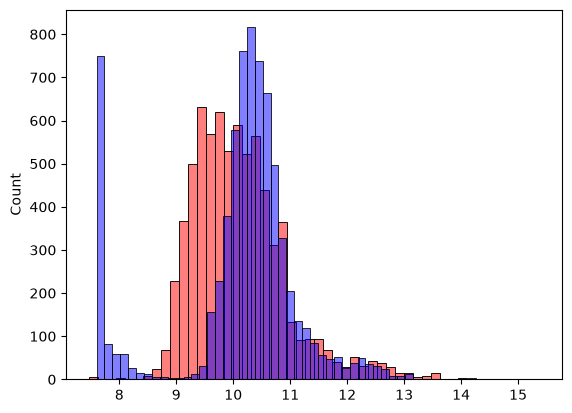

In [269]:
sns.histplot(y_pred, color='r', alpha=0.5, bins=50)
sns.histplot(y_train, color="blue", alpha=0.5, bins=50)

our model might not be ideal

**RMSE**

In [270]:
def rmse(y, y_pred):
    se = ( y - y_pred)**2
    mse = se.mean()
    return np.sqrt(mse)

In [271]:
rmse(y_train,y_pred)

np.float64(0.75832408690536)

**validating the model**

In [272]:
def prepare_X(df):
    X = df[base].fillna(0).values
    return X

In [273]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val =prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.7408999264107212)

**Simple feature engineering**

In [274]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [275]:

X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5153399596532275)

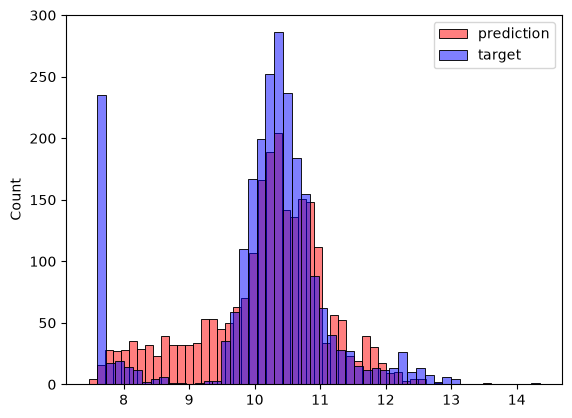

In [276]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()